# OBS004 — The Local JWST Environment of ASPECS C19

## Scientific Objective

The goal of this investigation is to characterize the galaxy environment surrounding the ASPECS source **C19** using deep JWST NIRCam F200W imaging.

Building on the measurements completed in **OBS003**, this notebook expands the field of view around C19 in order to:

- identify nearby galaxies,
- locate neighboring ASPECS CO detections,
- investigate possible physical companions,
- search for evidence of interactions or galaxy group membership,
- compare the stellar environments of C19 and nearby CO-selected galaxies.

Particular attention will be given to **CO ID 1**, whose proximity to C19 suggests it may provide important insight into the local environment.

---

## Expected Products

- Large JWST cutouts surrounding C19
- Catalog of nearby galaxies
- Identification of CO counterparts
- Environmental measurements
- Publication-quality figures

In [1]:
# ==========================================================
# Imports
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.nddata import Cutout2D

import astropy.units as u

from astropy.visualization import (
    ImageNormalize,
    PercentileInterval,
    AsinhStretch
)

from astropy.table import Table

In [2]:
# ==========================================================
# Project Paths
# ==========================================================

PROJECT = Path.cwd().parent

DATA = PROJECT / "data"
CATALOGS = DATA / "catalogs"
IMAGERY = DATA / "imagery"

FIGURES = PROJECT / "figures" / "obs004"
DOCS = PROJECT / "docs" / "observations"

FIGURES.mkdir(parents=True, exist_ok=True)

print(f"Project : {PROJECT}")
print(f"Figures : {FIGURES}")

Project : /home/glenn/Projects/CosmicIntelligenceLab
Figures : /home/glenn/Projects/CosmicIntelligenceLab/figures/obs004


In [3]:
# ==========================================================
# Target Information
# ==========================================================

c19 = SkyCoord(
    "03h32m38.53s",
    "-27d46m34.6s",
    frame="icrs"
)

print(c19)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.16054167, -27.77627778)>


# Phase 1 — Load the JWST F200W Mosaic

Load the calibrated JADES F200W mosaic that was identified and downloaded during OBS003.

This notebook begins with the existing science image rather than repeating the archive search performed previously.

In [4]:
# ==========================================================
# Phase 1
# Load JWST Science Image
# ==========================================================

jwst_file = (
    DATA
    / "raw"
    / "jwst"
    / "jw06541-o005_t005_nircam_clear-f200w_i2d.fits"
)

hdul = fits.open(jwst_file)

hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/raw/jwst/jw06541-o005_t005_nircam_clear-f200w_i2d.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     280   ()      
  1  SCI           1 ImageHDU        75   (9884, 4386)   float32   
  2  ERR           1 ImageHDU        10   (9884, 4386)   float32   
  3  CON           1 ImageHDU        10   (9884, 4386, 2)   int32   
  4  WHT           1 ImageHDU         9   (9884, 4386)   float32   
  5  VAR_POISSON    1 ImageHDU         9   (9884, 4386)   float32   
  6  VAR_RNOISE    1 ImageHDU         9   (9884, 4386)   float32   
  7  VAR_FLAT      1 ImageHDU         9   (9884, 4386)   float32   
  8  HDRTAB        1 BinTableHDU    536   48R x 263C   [23A, 5A, 3A, 45A, 7A, 13A, 3A, 5A, 5A, 7A, 10A, 4A, L, D, D, 32A, 50A, 104A, 13A, 2A, 10A, 12A, 23A, 23A, 26A, 11A, 5A, 3A, 3A, 2A, 1A, 2A, 1A, L, 14A, 2A, 26A, 20A, 27A, 10A, K, L, L, L, L, 11A, 1A, 5A, D, D, D, D, D, D, D, D, 6A, 5A, 1A, 

In [5]:
# ==========================================================
# Phase 1
# Prepare Image and WCS
# ==========================================================

jwst_image = hdul["SCI"].data

jwst_wcs = WCS(
    hdul["SCI"].header
)

jwst_norm = ImageNormalize(
    jwst_image,
    interval=PercentileInterval(99.5),
    stretch=AsinhStretch()
)

print(jwst_image.shape)

Set DATE-AVG to '2024-01-01T09:29:55.361' from MJD-AVG.
Set DATE-END to '2024-01-01T09:56:08.363' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to     8.851392 from OBSGEO-[XYZ].
Set OBSGEO-H to 1694081725.647 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


(4386, 9884)


In [6]:
# ==========================================================
# Phase 2
# Create a Large JWST Cutout
# ==========================================================

large_size = (800, 800)

large_cutout = Cutout2D(
    data=jwst_image,
    position=c19,
    size=large_size,
    wcs=jwst_wcs
)

print("Cutout shape:", large_cutout.data.shape)

Cutout shape: (800, 800)


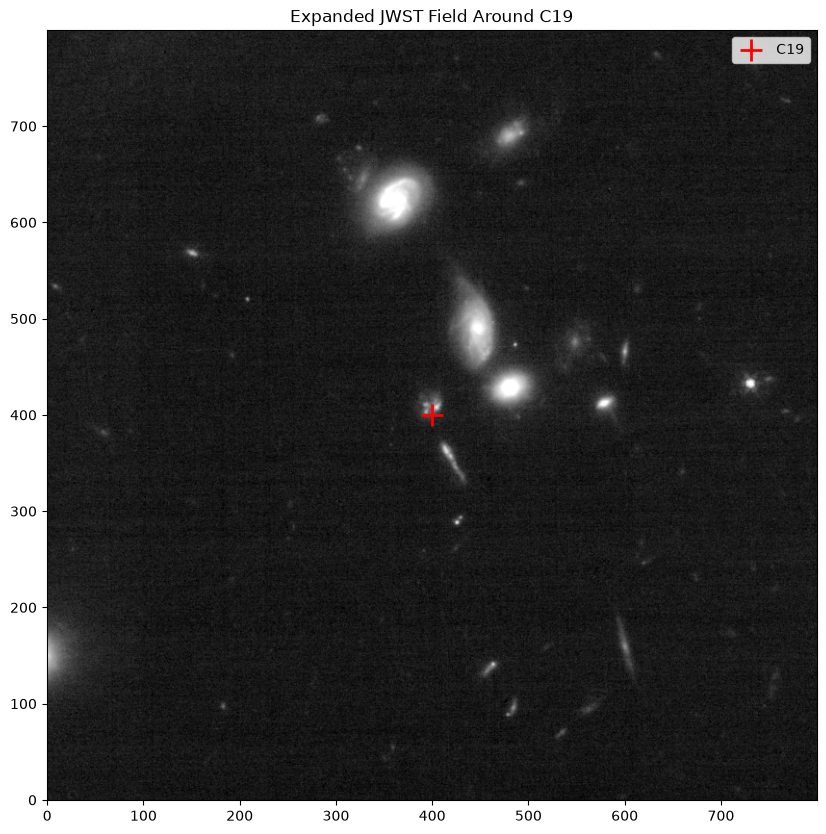

In [7]:
# ==========================================================
# Phase 2
# Display the Expanded JWST Field
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# C19 lies at the center of the cutout
ax.scatter(
    400,
    400,
    marker="+",
    s=250,
    color="red",
    linewidths=2,
    label="C19"
)

ax.set_title("Expanded JWST Field Around C19")

ax.legend()

plt.show()

In [8]:
# ==========================================================
# Phase 3
# Load the ASPECS CO Catalog
# ==========================================================

catalog = Table.read(
    CATALOGS / "aspecs_co_catalog.ecsv"
)

print(f"Number of CO sources: {len(catalog)}")

catalog[:5]

Number of CO sources: 18


id,ra,dec,z,jup,snr
str4,str11,str12,float64,int64,float64
1,03:32:38.54,-27:46:34.62,2.543,3,37.7
2,03:32:42.38,-27:47:07.92,1.317,2,17.9
3,03:32:41.02,-27:46:31.56,2.453,3,15.8
4,03:32:34.44,-27:46:59.82,1.414,2,15.5
5,03:32:39.76,-27:46:11.58,1.55,2,15.0


In [9]:
# ==========================================================
# Phase 3
# Convert CO Catalog to JWST Pixel Coordinates
# ==========================================================

co_coords = SkyCoord(
    catalog["ra"],
    catalog["dec"],
    unit=(u.hourangle, u.deg),
    frame="icrs"
)

co_x, co_y = large_cutout.wcs.world_to_pixel(co_coords)

# Keep only sources inside the 800×800 cutout
inside = (
    (co_x >= 0)
    & (co_x < large_cutout.data.shape[1])
    & (co_y >= 0)
    & (co_y < large_cutout.data.shape[0])
)

print(f"Sources inside cutout: {inside.sum()} of {len(catalog)}")

print(f"Sources inside field: {inside.sum()} of {len(catalog)}")

print(f"Converted {len(co_coords)} catalog positions.")

Sources inside cutout: 1 of 18
Sources inside field: 1 of 18
Converted 18 catalog positions.


NameError: name 'c19_x' is not defined

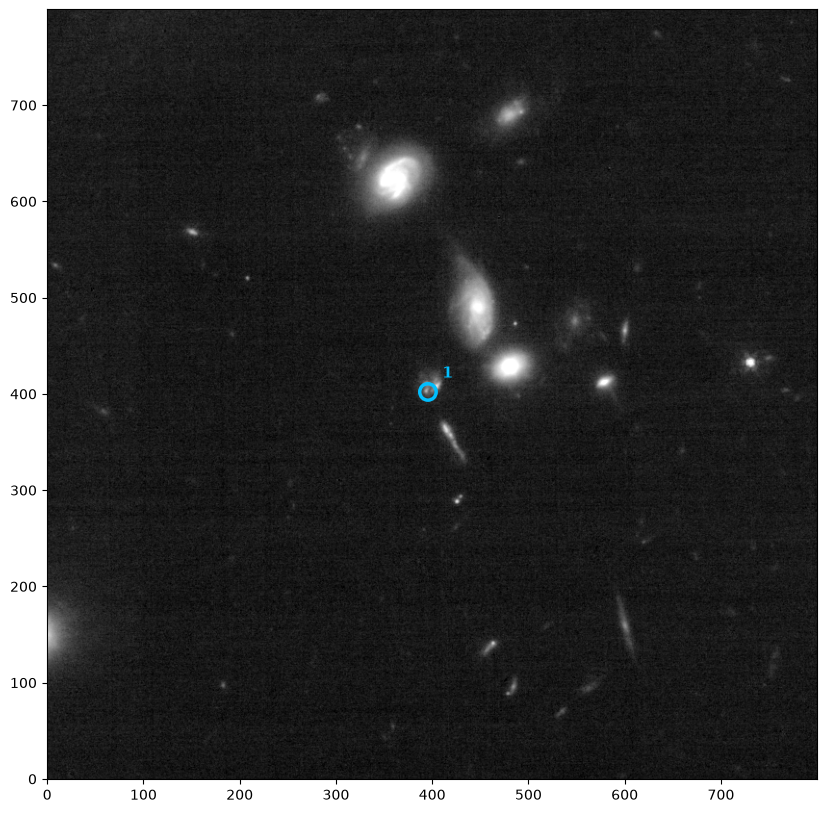

In [10]:
# ==========================================================
# Figure 2
# JWST Local Environment with ASPECS CO Catalog
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 10))

# JWST image
ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

# Plot ONLY the sources inside the cutout
ax.scatter(
    co_x[inside],
    co_y[inside],
    s=140,
    facecolors="none",
    edgecolors="deepskyblue",
    linewidths=2.5,
    label="ASPECS CO Source"
)

# Label them
for source_id, xpix, ypix in zip(
    catalog["id"][inside],
    co_x[inside],
    co_y[inside],
):
    ax.text(
        xpix + 15,
        ypix + 15,
        str(source_id),
        color="deepskyblue",
        fontsize=11,
        weight="bold"
    )

# Mark C19
ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    color="red",
    s=250,
    linewidths=2.5,
    label="C19"
)

ax.set_xlim(0, large_cutout.data.shape[1])
ax.set_ylim(0, large_cutout.data.shape[0])

ax.set_title("Figure 2 — JWST Local Environment with ASPECS CO Catalog")

ax.legend()

outfile = FIGURES / "fig2_c19_jwst_aspecs_catalog_overlay.png"

fig.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

print(outfile)

plt.show()

In [11]:
# ==========================================================
# Phase 4
# Candidate Neighboring Galaxies
# ==========================================================

neighbors = {
    "A": (365, 620),
    "B": (450, 490),
    "C": (500, 425),
    "D": (425, 350),
    "E": (585, 410),
    "F": (480, 690),
    "G": (475, 425),   # Bright compact galaxy
}

NameError: name 'c19_x' is not defined

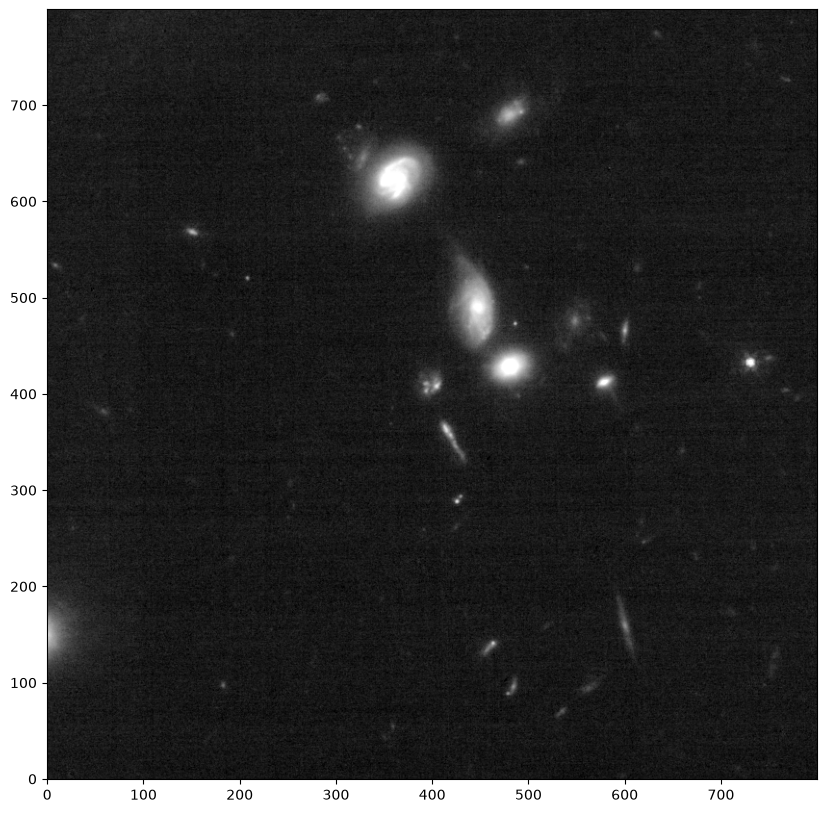

In [12]:
# ==========================================================
# Figure 3
# Candidate Neighboring Galaxies
# ==========================================================

fig, ax = plt.subplots(figsize=(10,10))

ax.imshow(
    large_cutout.data,
    origin="lower",
    cmap="gray",
    norm=jwst_norm
)

#
# Mark C19
#
ax.scatter(
    c19_x,
    c19_y,
    marker="+",
    s=250,
    color="red",
    linewidths=2.5,
    label="C19"
)

#
# Candidate neighbors
#
for label, (x, y) in neighbors.items():

    ax.scatter(
        x,
        y,
        s=120,
        facecolors="none",
        edgecolors="yellow",
        linewidths=2
    )

    ax.text(
        x + 12,
        y + 12,
        label,
        color="yellow",
        fontsize=13,
        weight="bold"
    )

ax.set_xlim(0, 800)
ax.set_ylim(0, 800)

ax.set_title("Figure 3 — Candidate Neighboring Galaxies Around C19")

ax.legend()

outfile = FIGURES / "fig3_c19_candidate_neighboring_galaxies.png"

fig.savefig(
    outfile,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [13]:
# ==========================================================
# Phase 5
# Convert Candidate Pixels to Sky Coordinates
# ==========================================================

candidate_coords = {}

for label, (x, y) in neighbors.items():

    sky = large_cutout.wcs.pixel_to_world(x, y)

    candidate_coords[label] = sky

    print(
        f"{label}: "
        f"RA={sky.ra.deg:.6f}°   "
        f"Dec={sky.dec.deg:.6f}°"
    )

A: RA=53.162303°   Dec=-27.775131°
B: RA=53.160814°   Dec=-27.775410°
C: RA=53.160017°   Dec=-27.775503°
D: RA=53.160019°   Dec=-27.776423°
E: RA=53.159322°   Dec=-27.775075°
F: RA=53.161988°   Dec=-27.773997°
G: RA=53.160190°   Dec=-27.775656°


In [14]:
# ==========================================================
# Phase 5
# Candidate Environment Table
# ==========================================================

from astropy.table import Table

environment = Table(
    names=[
        "Label",
        "RA_deg",
        "Dec_deg",
        "JADES_ID",
        "z_spec",
        "z_phot",
        "ALMA",
        "Notes",
    ],
    dtype=[
        "U2",
        float,
        float,
        "U32",
        float,
        float,
        "U10",
        "U80",
    ]
)

for label, sky in candidate_coords.items():

    environment.add_row([
        label,
        sky.ra.deg,
        sky.dec.deg,
        "",
        np.nan,
        np.nan,
        "",
        ""
    ])

environment

Label,RA_deg,Dec_deg,JADES_ID,z_spec,z_phot,ALMA,Notes
str2,float64,float64,str32,float64,float64,str10,str80
A,53.16230328033456,-27.775130613941744,,nan,nan,,
B,53.16081358085944,-27.77540960130518,,nan,nan,,
C,53.16001662025412,-27.77550319190905,,nan,nan,,
D,53.16001895997571,-27.77642320402161,,nan,nan,,
E,53.15932231785185,-27.77507523127794,,nan,nan,,
F,53.16198842926671,-27.773996558186457,,nan,nan,,
G,53.16019031376619,-27.77565618213005,,nan,nan,,


# Phase 5A — Acquire the JADES Reference Catalog

The local environment of C19 will be investigated using the official
JADES Data Release 5 (DR5) photometric catalog.

This catalog provides:

- Source identifiers
- Accurate celestial coordinates
- Multi-band photometry
- Photometric redshifts
- Additional derived source properties

The catalog will become a permanent reference dataset for the
Cosmic Intelligence Lab.

In [16]:
# ==========================================================
# Phase 5A
# Create JADES Catalog Directory
# ==========================================================

JADES = CATALOGS / "jades"

JADES.mkdir(
    parents=True,
    exist_ok=True
)

print(JADES)

/home/glenn/Projects/CosmicIntelligenceLab/data/catalogs/jades


In [17]:
# ==========================================================
# Configure Python Import Path
# ==========================================================

import sys

if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

print(PROJECT)

/home/glenn/Projects/CosmicIntelligenceLab


In [18]:
from cosmic.catalogs import load_jades_catalog

print("Import successful!")

Import successful!


In [19]:
# ==========================================================
# Phase 5A
# Load the JADES DR5 Catalog
# ==========================================================

from cosmic.catalogs import load_jades_catalog

jades = load_jades_catalog(PROJECT)

Cosmic Intelligence Lab
Loading JADES DR5 Photometric Catalog
/home/glenn/Projects/CosmicIntelligenceLab/data/catalogs/jades/dr5/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits

Loaded 35 catalog entries.


In [20]:
# ==========================================================
# Inspect the JADES FITS File
# ==========================================================

from astropy.io import fits

filename = (
    CATALOGS
    / "jades"
    / "dr5"
    / "hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits"
)

with fits.open(filename, memmap=True) as hdul:
    hdul.info()

Filename: /home/glenn/Projects/CosmicIntelligenceLab/data/catalogs/jades/dr5/hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      63   ()      
  1  FILTERS       1 BinTableHDU     85   35R x 12C   [6A, E, E, E, E, E, E, E, E, E, E, E]   
  2  FLAG          1 BinTableHDU    333   304366R x 108C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, J, J, J]   
  3  SIZE          1 BinTableHDU    103   304366R x 18C   [J, D, D, D, D, D, D, K, K, K, K, D, D, D, D, D, D, D]   
  4  CIRC          1 BinTableHDU   1757   304366R x 570C   [J, D, D, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E,

In [21]:
from astropy.table import Table

filename = (
    CATALOGS
    / "jades"
    / "dr5"
    / "hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits"
)

photoz = Table.read(filename, hdu="PHOTOZ")

print(len(photoz))
print()
print(photoz.colnames)

304366

['ID', 'z_spec', 'z_a', 'z_ml', 'chi_a', 'l68', 'u68', 'l95', 'u95', 'l99', 'u99', 'nfilt', 'z_peak', 'chi_peak', 'z025', 'z160', 'z500', 'z840', 'z975', 'Prob_gt_5', 'Prob_gt_6', 'Prob_gt_7', 'Prob_gt_8', 'Prob_gt_9', 'chisq_z_lt_7', 'z_chisq_z_lt_7', 'chisq_z_lt_6', 'z_chisq_z_lt_6', 'chisq_z_lt_5', 'z_chisq_z_lt_5', 'chisq_z_lt_4', 'z_chisq_z_lt_4', 'z_bins', 'Prob_z_bins']


In [22]:
from astropy.io import fits

filename = (
    CATALOGS
    / "jades"
    / "dr5"
    / "hlsp_jades_jwst_nircam_goods-s_photometry_v5.0_catalog.fits"
)

with fits.open(filename, memmap=True) as hdul:
    for i, hdu in enumerate(hdul):
        print(f"{i:2d}  {hdu.name}")

 0  PRIMARY
 1  FILTERS
 2  FLAG
 3  SIZE
 4  CIRC
 5  CIRC_BSUB
 6  CIRC_CONV
 7  CIRC_BSUB_CONV
 8  KRON
 9  KRON_CONV
10  MIRI
11  PHOTOZ
12  PHOTOZ_KRON


In [23]:
kron = Table.read(filename, hdu="KRON")

print(len(kron))
print()

for col in kron.colnames[:50]:
    print(col)

304366

ID
RA
DEC
A_KRON
B_KRON
THETA_KRON
F070W_KRON
F070W_KRON_e
F070W_KRON_ei
F070W_KRON_bkg
A_KRON_S
B_KRON_S
THETA_KRON_S
F070W_KRON_S
F070W_KRON_S_e
F070W_KRON_S_ei
F070W_KRON_S_bkg
F090W_KRON
F090W_KRON_e
F090W_KRON_ei
F090W_KRON_bkg
F090W_KRON_S
F090W_KRON_S_e
F090W_KRON_S_ei
F090W_KRON_S_bkg
F105W_KRON
F105W_KRON_e
F105W_KRON_ei
F105W_KRON_bkg
F105W_KRON_S
F105W_KRON_S_e
F105W_KRON_S_ei
F105W_KRON_S_bkg
F115W_KRON
F115W_KRON_e
F115W_KRON_ei
F115W_KRON_bkg
F115W_KRON_S
F115W_KRON_S_e
F115W_KRON_S_ei
F115W_KRON_S_bkg
F125W_KRON
F125W_KRON_e
F125W_KRON_ei
F125W_KRON_bkg
F125W_KRON_S
F125W_KRON_S_e
F125W_KRON_S_ei
F125W_KRON_S_bkg
F140W_KRON
